# Filtros de Fase Linear usando Janelamento

## Bibliotecas

In [714]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.signal as signal

## Parte 1

1. Gere um sinal de entrada $x[n]$ que é a soma de três funções cosseno com frequências angulares iguais a 0,2π, 0,5π e 0,8π, e amplitudes iguais a 1. Este sinal deve possuir N=200 pontos. Gere o gráfico do módulo da Transformada de Fourier deste sinal $x[n]$ em dB. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a módulo da Transformada de Fourier está de acordo com o esperado.

Gerando o sinal $ x[n] $ formado por cossenos com as seguintes frequências: $ 0,2\pi $, $ 0,5\pi $ e $ 0,8\pi $ com aplitude igual a 1

In [715]:
x_N = 200

x_n = np.arange(x_N)
x = np.cos(0.2 * np.pi * x_n) + \
    np.cos(0.5 * np.pi * x_n) + \
    np.cos(0.8 * np.pi * x_n)

Calculando a Transformada de Fourier do sinal $ x[n] $ 

In [716]:
X        = np.fft.fft(x)
X_abs    = np.abs(X)
X_abs_dB = 20 * np.log10(X_abs)

x_freqs            = np.fft.fftfreq(x_N, d = 1)
x_freqs            = np.fft.fftshift(x_freqs)
x_freqs_normalized = 2 * np.pi * x_freqs

Representação gráfica do sinal no tempo e na frequência

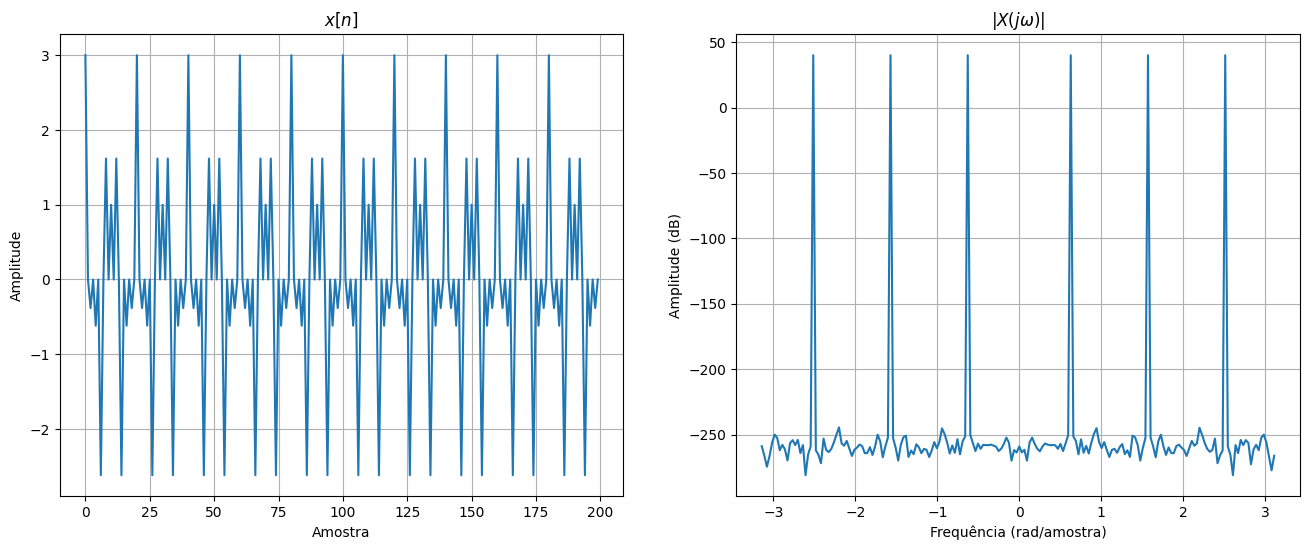

In [717]:
figure, axes = plt.subplots(1, 2, figsize = (16, 6))

axes[0].plot(x_n, x)
axes[0].set_title("$ x[n] $")
axes[0].set_xlabel("Amostra")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(x_freqs_normalized, X_abs_dB)
axes[1].set_title("$ |X(j\\omega)| $")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Amplitude (dB)")
axes[1].grid(True)

plt.show()
plt.close()


Esse gráfico gerado está coerente com o esperado. Visto que a TF do $ cos(\omega x)$ é $ \pi(\delta(\omega - \omega_0) + \delta(\omega - \omega_0))$, temos 6 impulsos gerados pelos 3 cossenos, localizados em suas respectivas frequêcias, que forma o sinal $ x[n] $ 

2. Gere a resposta ao impulso $h[n]$ de um filtro passa-baixa FIR usando truncamento (janela retangular) a partir um filtro passa-baixa ideal com frequência de corte igual a 0,65π e atraso α=15. A resposta ao impulso deste filtro deve ser não nula de 0 até M=2α=30. Gere o gráfico do módulo da Resposta em Frequência deste sistema em dB (ou seja, da Transformada de Fourier da resposta ao impulso $h[n]$). Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a módulo da Resposta em Frequência está de acordo com o esperado.

Gerando a resposta ao impulso $h[n]$ de um filtro passa-baixa FIR usando uma janela retangular:

In [718]:
alpha = 15
M     = 2 * alpha
n     = np.arange(M + 1)
wc    = 0.65 * np.pi

In [719]:
h = np.zeros_like(n, dtype = float)

for i, k in enumerate(n):
    if k == alpha:
        h[i] = wc / np.pi
    else:
        h[i] = np.sin(wc * (k - alpha)) / (np.pi * (k - alpha))

Calculando a resposta em frequência do filtro

In [720]:
N_h_fft = 2048

H = np.fft.fft(h, N_h_fft)
H = np.fft.fftshift(H)

H_abs    = np.abs(H)
H_abs_dB = 20 * np.log10(H_abs)

H_frequencies = np.linspace(-np.pi, np.pi, N_h_fft)

Representação gráfica do filtro no tempo e na frequência

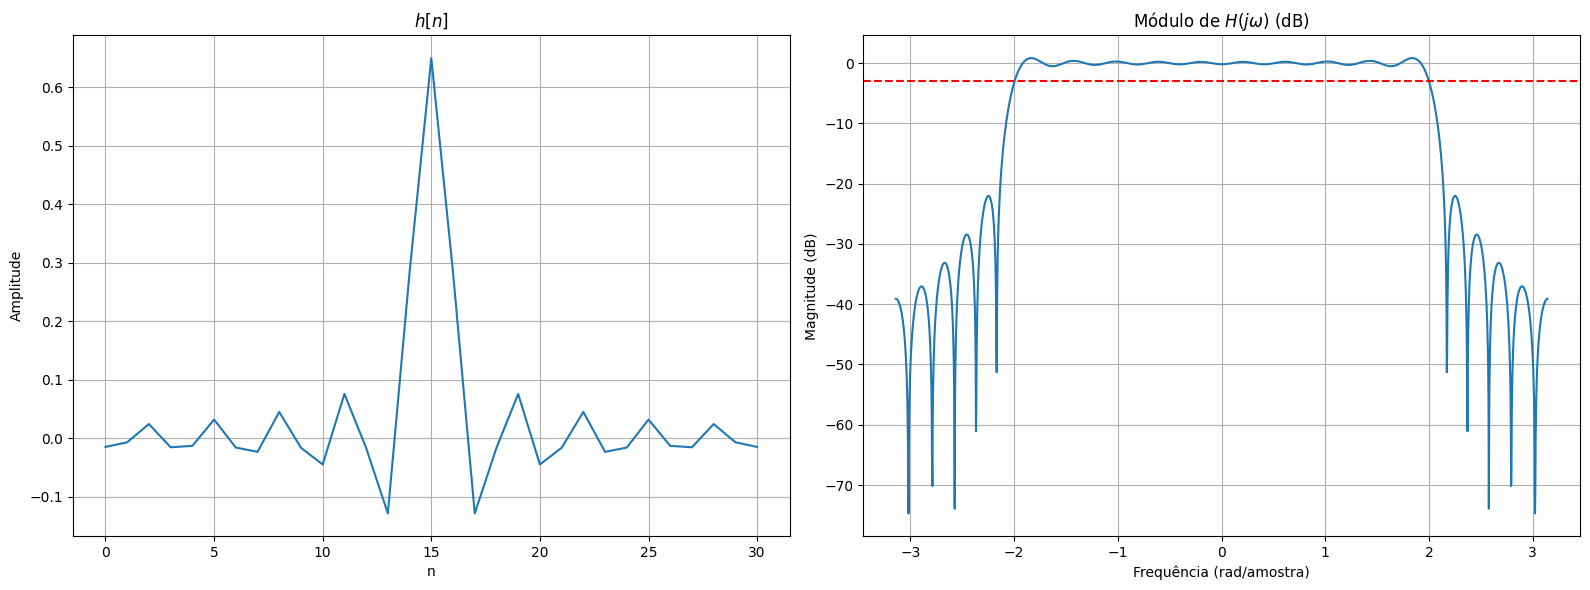

In [721]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(n, h)
axes[0].set_title("$h[n]$")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(H_frequencies, H_abs_dB)
axes[1].set_title("Módulo de $H(j\\omega)$ (dB)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].axhline(y = -3, color = 'red', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Como sabemos, um $sinc$ no tempo é uma janela retangular na na frequência. Perceba que na frequência que acontece a quedra de 3dB, é onde a frequência de corte $\omega_c$ é estipulada. Além disso, como estamos usando uma janela retangular, há lóbulos secundários relevantes na faixa de rejeitção. Dessa forma, o gráfico está coerente com o esperado. 

3. Gere o gráfico da resposta em fase deste sistema (com fase contínua, usando unwrap. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a fase da Resposta em Frequência está de acordo com o esperado.

Calculando a resposta em fase do sistema $h$

In [722]:
H_phase        = np.angle(H)
H_phase_unwrap = np.unwrap(H_phase)

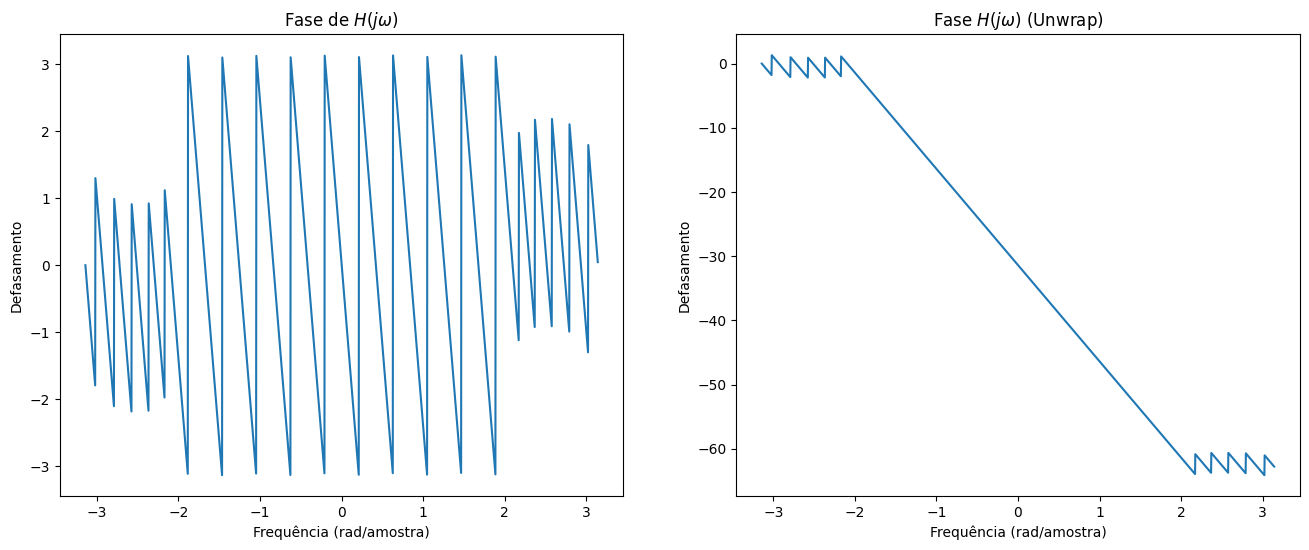

In [723]:
figure, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

axes[0].plot(H_frequencies, H_phase)
axes[0].set_title("Fase de $ H(j\\omega) $")
axes[0].set_xlabel("Frequência (rad/amostra)")
axes[0].set_ylabel("Defasamento")

axes[1].plot(H_frequencies, H_phase_unwrap)
axes[1].set_title("Fase $ H(j\\omega) $ (Unwrap)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Defasamento")

plt.show()
plt.close()

Observamos uma fase linear no intervalo do $ [-\omega_c; \omega_c] $ com declividade $ \alpha = 15 $. Portanto, o gráfico satisfaz nossas espectativas

4. Gere o gráfico do atraso de grupo deste sistema (pode usar a função pronta para o cálculo do atraso de grupo). Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se o atraso de grupo está de acordo com o esperado.

Calculando o atraso de grupo numericamente

In [724]:
d_H_phase_unwrap = np.diff(H_phase_unwrap)
d_H_frequencies  = np.diff(H_frequencies)

H_group_delay = - d_H_phase_unwrap / d_H_frequencies

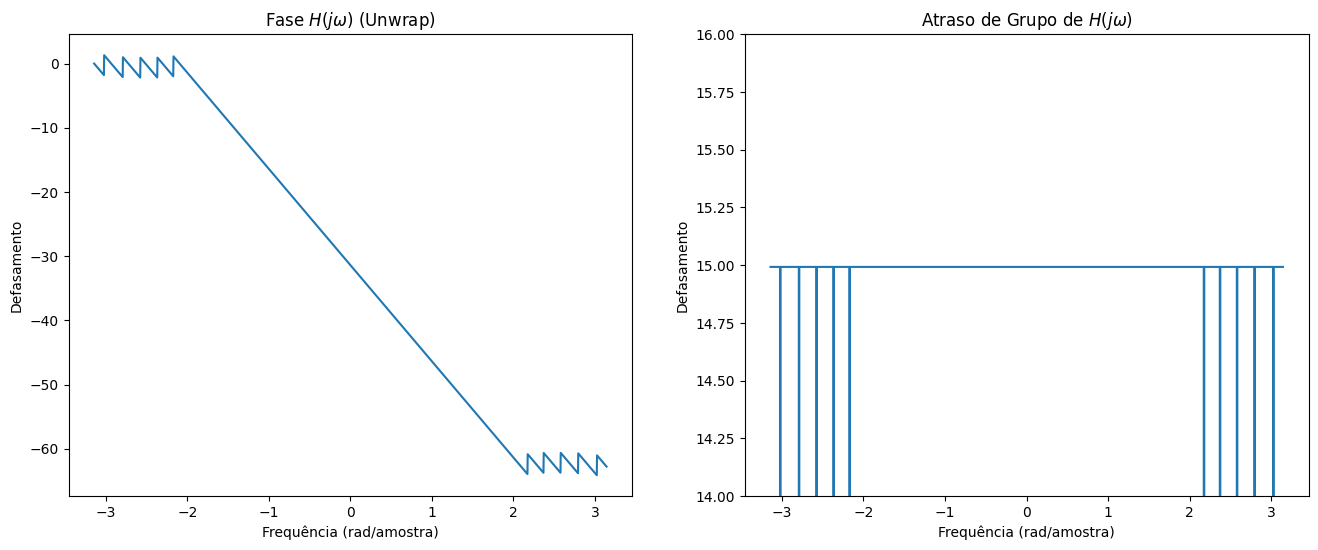

In [725]:
figure, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

axes[0].plot(H_frequencies, H_phase_unwrap)
axes[0].set_title("Fase $ H(j\\omega) $ (Unwrap)")
axes[0].set_xlabel("Frequência (rad/amostra)")
axes[0].set_ylabel("Defasamento")

axes[1].plot(H_frequencies[1:], H_group_delay)
axes[1].set_title("Atraso de Grupo de $ H(j\\omega) $")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Defasamento")
axes[1].set_ylim(14, 16)

plt.show()
plt.close()

O atraso de grupo esperado é uma reta horizontal em $ y = 15 $ para a faixa $ [-\omega_c; \omega_c] $. Dessa forma, está como esperado

5. Filtre o sinal x[n] da Questão 1 usando a resposta ao impulso h[n] gerada na Questão 2. Gere o gráfico do módulo da Transformada de Fourier da saída y[n] em dB. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se o módulo da Transformada de Fourier do sinal filtrado está de acordo com o esperado.

Realizando a convolução de $ y[n] = x[n] \ast h[n] $

In [726]:
y   = np.convolve(x, h)
y_n = np.arange(y.size)

Calculando a Transformada de Fourier de $ y[n] $

In [727]:
N_y_fft = 2048

Y = np.fft.fft(y, N_y_fft)
Y = np.fft.fftshift(Y)

Y_abs    = np.abs(Y)
Y_abs_dB = 20 * np.log10(Y_abs)

Y_frequencies = np.linspace(-np.pi, np.pi, N_y_fft)

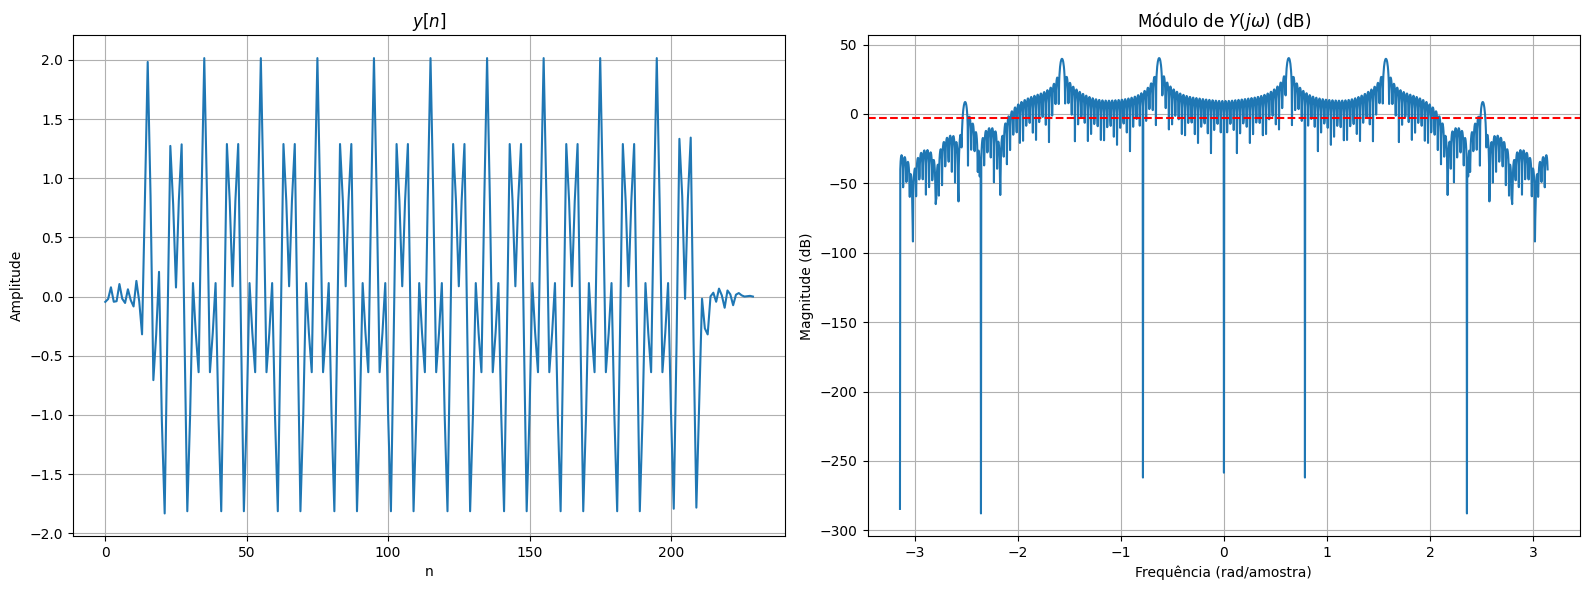

In [728]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(y_n, y)
axes[0].set_title("$y[n]$")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(Y_frequencies, Y_abs_dB)
axes[1].set_title("Módulo de $Y(j\\omega)$ (dB)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].axhline(y = -3, color = 'red', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Realizando a convolução de $ y[n] = x[n] \ast h[n] $

In [729]:
y   = np.convolve(x, h)
y_n = np.arange(y.size)

Calculando a Transformada de Fourier de $ y[n] $

In [730]:
N_y_fft = 2048

Y = np.fft.fft(y, N_y_fft)
Y = np.fft.fftshift(Y)

Y_abs    = np.abs(Y)
Y_abs_dB = 20 * np.log10(Y_abs)

Y_frequencies = np.linspace(-np.pi, np.pi, N_y_fft)

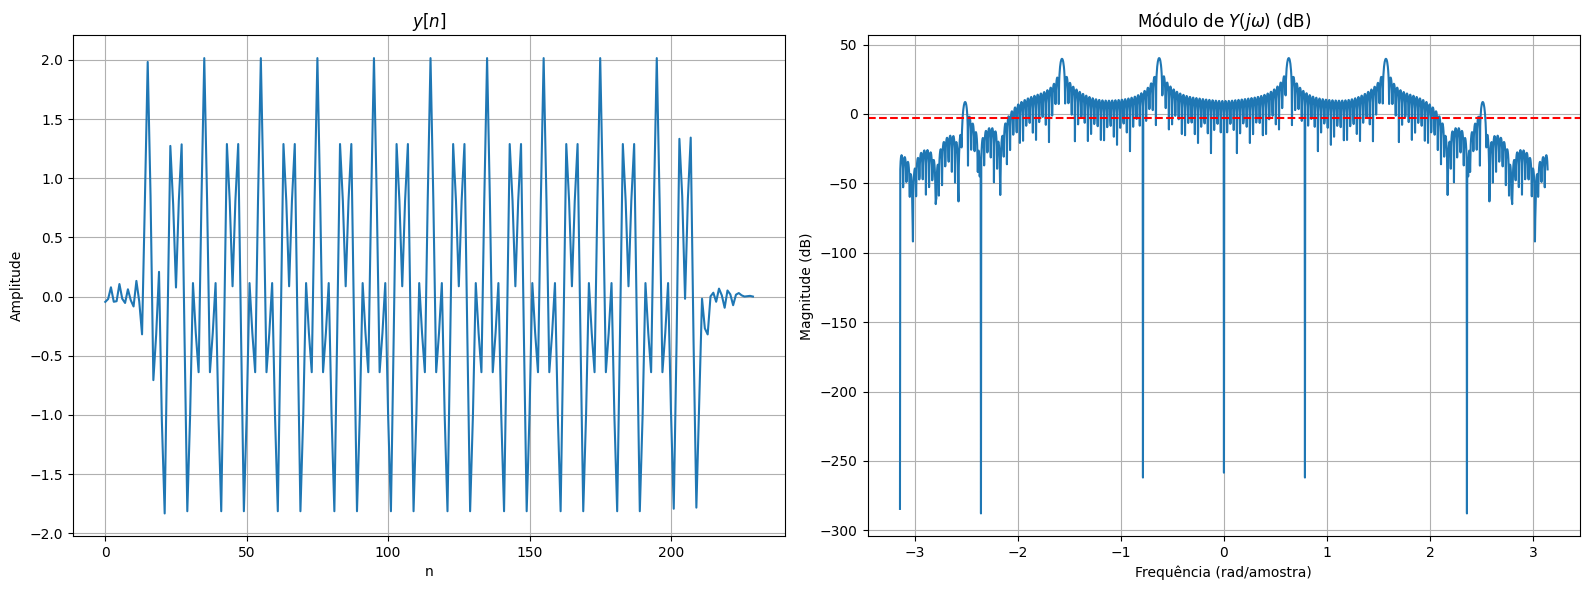

In [731]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(y_n, y)
axes[0].set_title("$y[n]$")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(Y_frequencies, Y_abs_dB)
axes[1].set_title("Módulo de $Y(j\\omega)$ (dB)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].axhline(y = -3, color = 'red', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Como podemos notar, a componente $\cos(0.8\pi x)$ foi atenuada pelo filtro. Isso é esperado já que estamos utilizando um filtro passa-baixa com frequência de corte $ \omega_c = 0.65\pi $. Daí, componentes com frequências acima de $ \omega_c $ são atenuadas

6. O sinal de saída y[n] deve ser, de forma aproximada, igual a um sinal g[n] que corresponde à soma de dois cossenos com frequências angulares igual a 0,2π e 0,5π, mas com um atraso igual a α. Para saber se isto realmente está acontecendo, gere, em um mesmo gráfico, os sinais g[n-α] e y[n], e comente se estes sinais são parecidos e sincronizados.

Gerando o sinal $ g[n] $

In [732]:
g = np.cos(0.2 * np.pi * (y_n - alpha)) + \
    np.cos(0.5 * np.pi * (y_n - alpha))

Gerando o sinal $ e[n] = g[n] - y[n] $

In [733]:
e = g - y

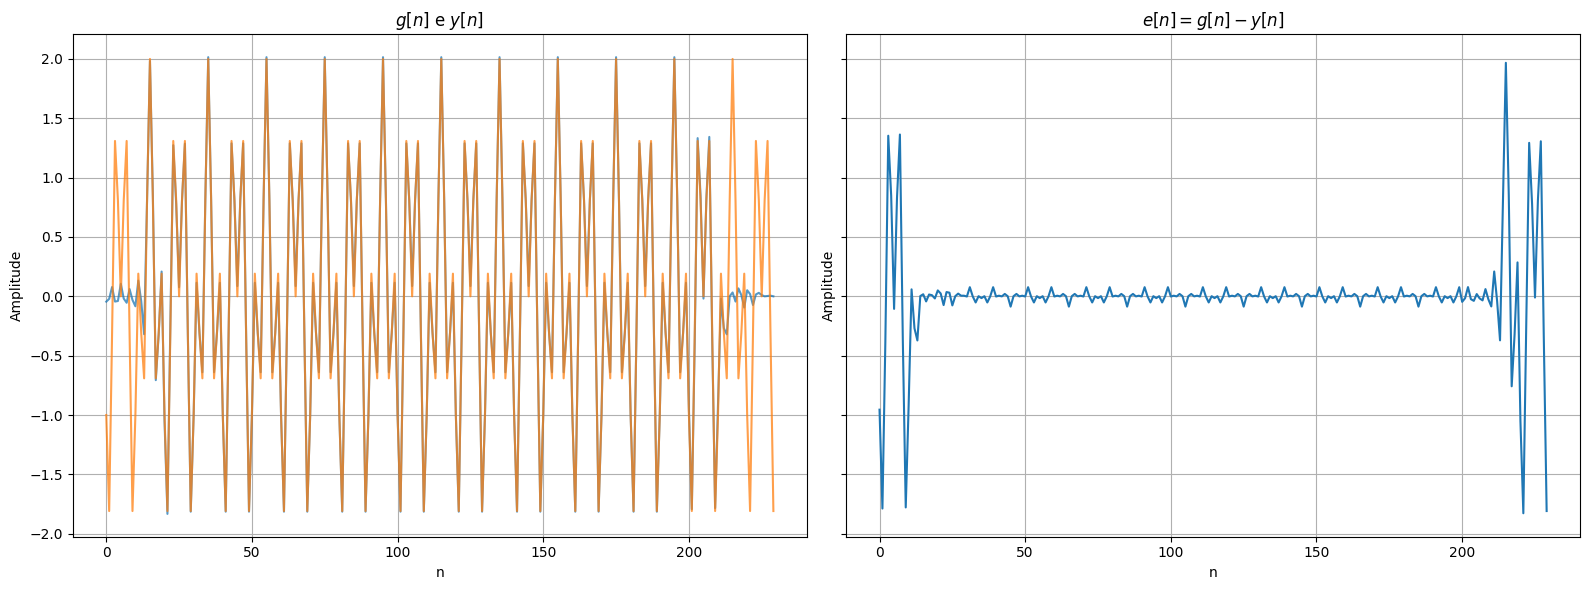

In [734]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey = True)

axes[0].plot(y_n, y, alpha = 0.75)
axes[0].plot(y_n, g, alpha = 0.75)
axes[0].set_title("$ g[n] $ e $ y[n] $")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(y_n, e)
axes[1].set_title("$ e[n] = g[n] - y[n] $")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Sim. Os gráficos são parecidos e sincronizados. Exceto nas bordas

## Parte 2

7. Gere os coeficientes $a_k$ e $b_k$ da equação de diferenças de um filtro passa-baixa IIR de Butterworth com frequência de corte igual a 0,65π e ordem igual a 8. Use uma função pronta para gerar o filtro de Butterworth. Gere o gráfico do módulo da Resposta em Frequência deste sistema em dB. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a módulo da Resposta em Frequência está de acordo com o esperado.

Parameros do filtro passa-baixa IRR Butterworth

In [735]:
wc            = 0.65 * np.pi
wc_normalized = wc / np.pi

order      = 8
filterType = 'lowpass'

Coeficientes $a_k$ e $b_k$

In [736]:
b_k, a_k = signal.butter(
    N      = order, 
    Wn     = wc_normalized, 
    btype  = filterType, 
)

print("b_k =", b_k)
print("a_k =", a_k)

b_k = [0.04879474 0.39035791 1.36625267 2.73250535 3.41563168 2.73250535
 1.36625267 0.39035791 0.04879474]
a_k = [1.00000000e+00 2.38697983e+00 3.36960116e+00 2.96409892e+00
 1.79747431e+00 7.38048925e-01 2.00473711e-01 3.23942876e-02
 2.38186806e-03]


Calculando a resposta em frequência do filtro

In [737]:
H_frequencies, H = signal.freqz(b_k, a_k, worN = 2048)

H_abs = np.abs(H)
H_dB  = 20 * np.log10(H_abs)

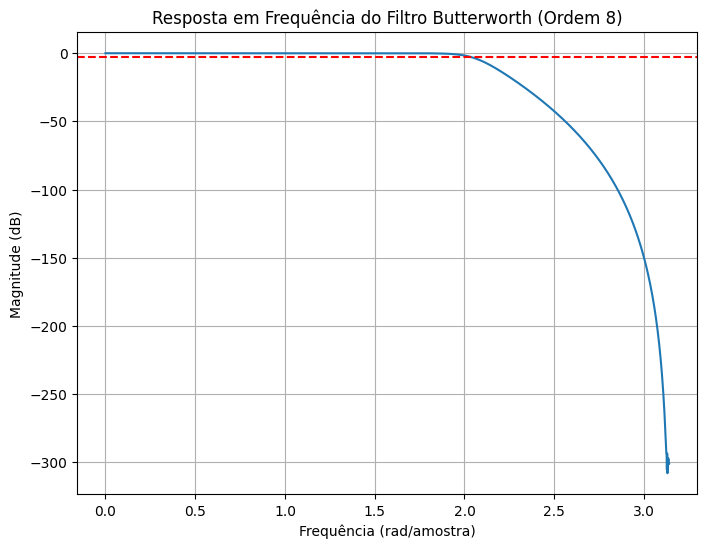

In [738]:
plt.figure(figsize = (8, 6))

plt.title("Resposta em Frequência do Filtro Butterworth (Ordem 8)")

plt.plot(H_frequencies, H_dB) 

plt.xlabel("Frequência (rad/amostra)")
plt.ylabel("Magnitude (dB)")
plt.axhline(y = -3, color = 'red', linestyle='--')

plt.grid(True)

plt.show()
plt.close()

O gráfico mostra que na banda de passagem plana caracterísitca de filtros com janelamento butterworth. Além disso, há uma queda de -3dB na frequência de corte especificada $\omega_c = 0.65\pi$. Portanto, o gráfico está como esperado

8. Gere o gráfico da resposta em fase deste sistema (com fase contínua, usando unwrap. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a fase da Resposta em Frequência está de acordo com o esperado.

In [739]:
H_phase        = np.angle(H)
H_phase_unwrap = np.unwrap(H_phase)

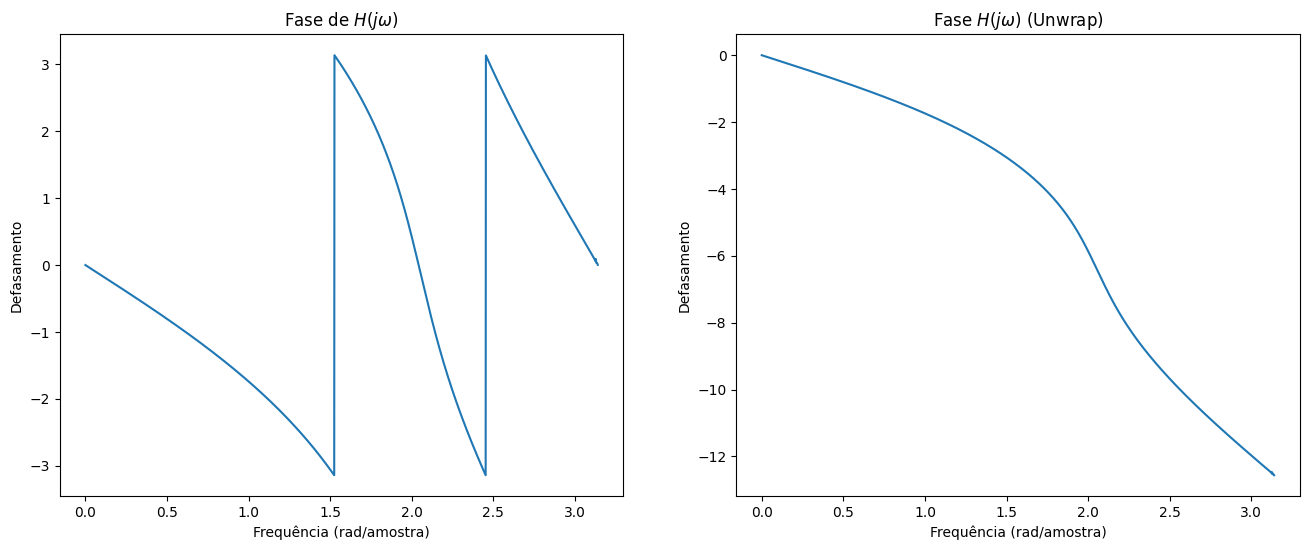

In [740]:
figure, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

axes[0].plot(H_frequencies, H_phase)
axes[0].set_title("Fase de $ H(j\\omega) $")
axes[0].set_xlabel("Frequência (rad/amostra)")
axes[0].set_ylabel("Defasamento")

axes[1].plot(H_frequencies, H_phase_unwrap)
axes[1].set_title("Fase $ H(j\\omega) $ (Unwrap)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Defasamento")

plt.show()
plt.close()

Diferentemente de filtros de fase linear, o filtro Butterworth é caracterizado por ter uma resposta de frequência maximamente plana na banda passante, mas isso é obtido ao custo de uma mudança de fase não-linear. Portanto, o gráfico está como esperado

9. Gere o gráfico do atraso de grupo deste sistema (pode usar a função pronta para o cálculo do atraso de grupo). Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se o atraso de grupo está de acordo com o esperado.

Calculando o atraso de grupo numericamente

In [741]:
d_H_phase_unwrap = np.diff(H_phase_unwrap)
d_H_frequencies  = np.diff(H_frequencies)

H_group_delay = - d_H_phase_unwrap / d_H_frequencies

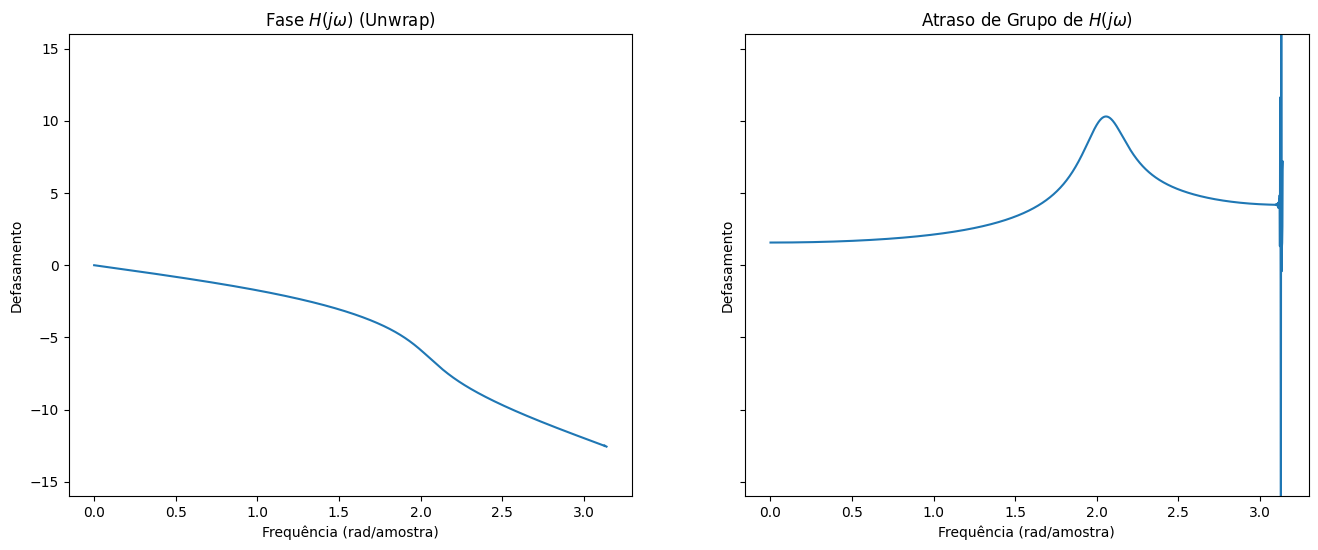

In [742]:
figure, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6), sharey = True)

axes[0].plot(H_frequencies, H_phase_unwrap)
axes[0].set_title("Fase $ H(j\\omega) $ (Unwrap)")
axes[0].set_xlabel("Frequência (rad/amostra)")
axes[0].set_ylabel("Defasamento")

axes[1].plot(H_frequencies[1:], H_group_delay)
axes[1].set_title("Atraso de Grupo de $ H(j\\omega) $")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Defasamento")

plt.ylim(-16, 16)

plt.show()
plt.close()

Como a mudança da fase não é linear. Então, o atraso de grupo também não é. Portanto, o gráfico está como esperado

10. Filtre o sinal x[n] da Questão 1 usando os coeficientes ak e bk da equação de diferenças gerados na Questão 7. Gere o gráfico do módulo da Transformada de Fourier da saída y[n] em dB. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se o módulo da Transformada de Fourier do sinal filtrado está de acordo com o esperado.

Aplicando o filtro no sinal $x[n]$

In [743]:
y = signal.lfilter(b_k, a_k, x)

Calculando a Transformada de Fourier de $ y[n] $

In [744]:
N_y_fft = 2048

Y = np.fft.fft(y, N_y_fft)
Y = np.fft.fftshift(Y)

Y_abs    = np.abs(Y)
Y_abs_dB = 20 * np.log10(Y_abs)

Y_frequencies = np.linspace(-np.pi, np.pi, N_y_fft)

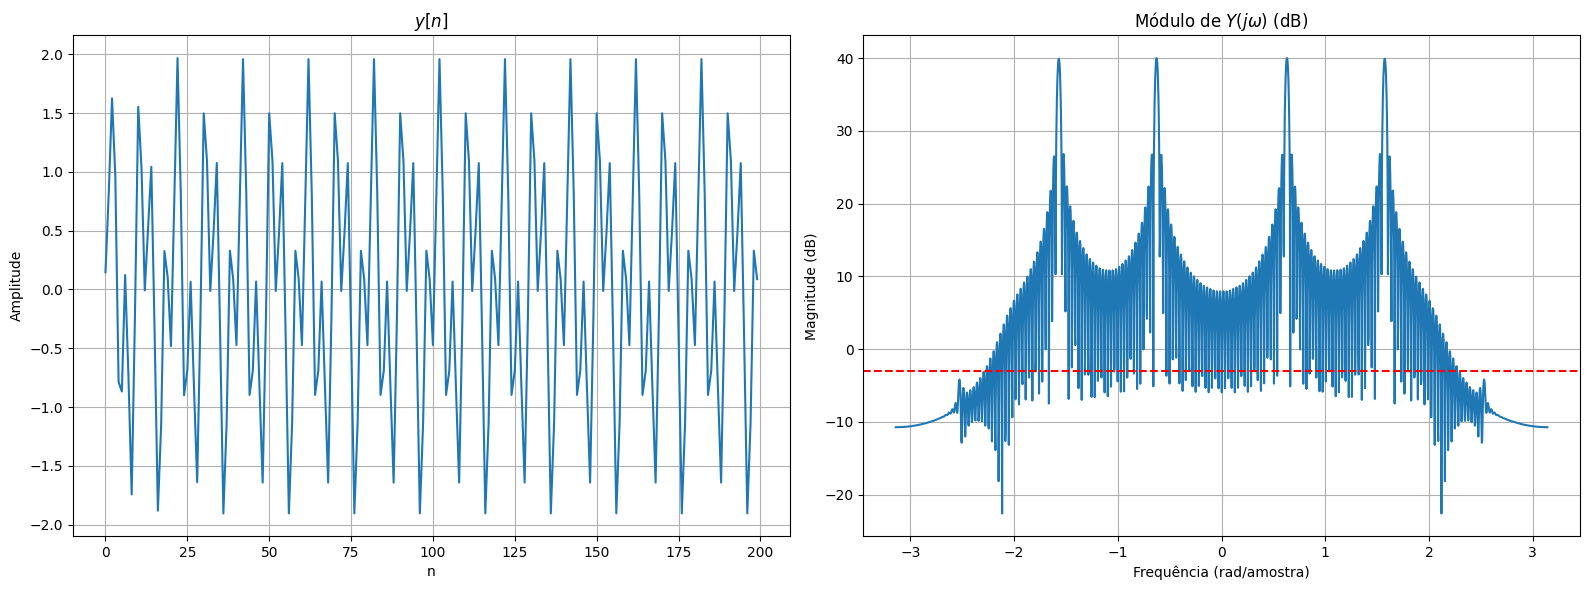

In [745]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_n, y)
axes[0].set_title("$y[n]$")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(Y_frequencies, Y_abs_dB)
axes[1].set_title("Módulo de $Y(j\\omega)$ (dB)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].axhline(y = -3, color = 'red', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

O filtro Butterworth passa-baixa (fc = 0.65π) deve atenuar de forma suave a componente de maior frequência. Logo, no gráfico devem aparecer dois picosfortes em 0.2π e 0.5π. Portanto, o gráfico está como esperado

11. Novamente, o sinal de saída y[n] deve ser, de forma aproximada, igual a um sinal g[n] que corresponde à soma de dois cossenos com frequências angulares igual a 0,2π e 0,5π, mas com um atraso. Entretanto, desta vez, o atraso do sinal g[n] não pode ser determinado a priori. Este atraso deve ser estimado a partir do atraso de grupo. Para saber se isto realmente está acontecendo, gere, em um mesmo gráfico, os sinais g[n-nd] e y[n], em que nd é um atraso que você deve estimar a partir do atraso de grupo. Comente se estes sinais são parecidos e sincronizados.

Estimando o $n_d$ pela média dos atrasos das frequências $0,2\pi$ e $0,5\pi$

In [746]:
idx_02 = np.argmin(np.abs(H_frequencies - 0.2 * np.pi))
idx_05 = np.argmin(np.abs(H_frequencies - 0.5 * np.pi))

nd = int((H_group_delay[idx_02] + H_group_delay[idx_05]) / 2)

print("nd =", nd, "amostras")

nd = 2 amostras


Gerando o sinal $ g[n] $

In [747]:
g = np.cos(0.2 * np.pi * (x_n - nd)) + \
    np.cos(0.5 * np.pi * (x_n - nd))

Gerando o sinal $ e[n] = g[n] - y[n] $

In [748]:
e = g - y

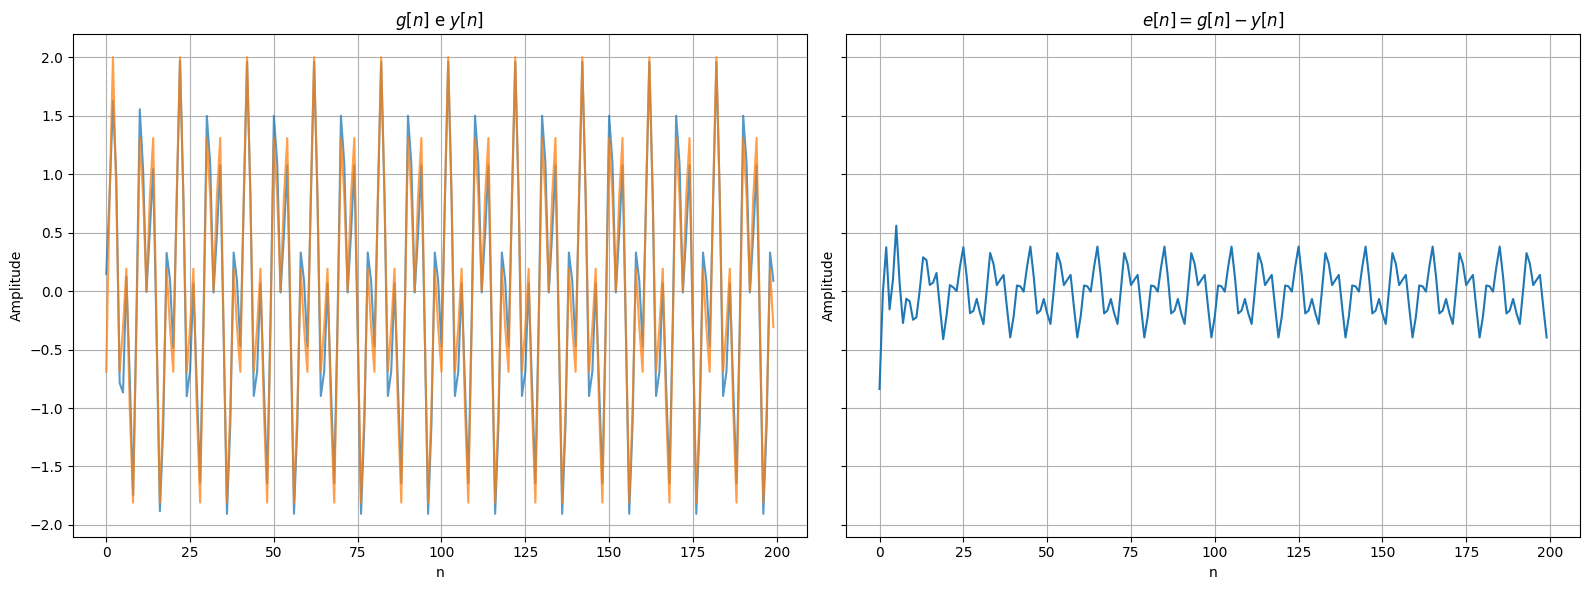

In [749]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey = True)

axes[0].plot(x_n, y, alpha = 0.75)
axes[0].plot(x_n, g, alpha = 0.75)
axes[0].set_title("$ g[n] $ e $ y[n] $")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(x_n, e)
axes[1].set_title("$ e[n] = g[n] - y[n] $")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Sim. A diferença entre o sinal $g[n]$ e $y[n]$ é relativamente baixa como podemos analisar no sinal $e[n]$. Entretanto, não é um ajuste perfeito visto que a atraso de grupo não é uniforme e, então, não conseguimos estimalo perfeitamente só com o calculo da média 

## Parte 3

12. Projete um filtro passa-baixa FIR usando o Método do Janelamento com as seguintes especificações: wp = 0,6π, ws = 0,7π, ẟ1 = 0,01 e ẟ2 = 0,05. Para a completa especificação do filtro, você deve dizer os valores de: Janela usada (retangular, Bartlett, Hanning, Hamming ou Nlackman), ordem do filtro (M), frequência de corte (w c) e atraso do filtro ideal (ɑ). Para esta questão, usa a tabela que se encontra nos slides da disciplina. Coloque a resposta em forma de comentário no código

Parametros do filtro

In [750]:
wp = 0.6 * np.pi
ws = 0.7 * np.pi

delta_1 = 0.01
delta_2 = 0.05

Calculando a atenuação desejada

In [751]:
delta_min          = np.min([delta_1, delta_2])
target_attenuation = 20 * np.log10(delta_min)

target_attenuation

np.float64(-40.0)

Analisando a tabela de janelamento disponível nos slides da disciplina, escolheremos a **janela Hamming** por apresentar a menor banda de transição para a atenuação desejada

Calculando a ordem $M_{janela}$ do filtro usanda a relação $\Delta w = \frac{3.3\pi}{M} \Rightarrow M = \frac{3.3\pi}{\Delta w}$ 

In [752]:
delta_w = ws - wp

M_janela = 3.3 * np.pi / delta_w 

M_janela

33.0

Calculando a frequencia de corte $\omega_c$

In [753]:
wc = (wp + ws) / 2
wc

2.0420352248333655

Calculando o atraso $n_d$

In [754]:
nd = round(M_janela / 2)
nd

16

13. Repita a Questão 12 usando Janela de Kaiser. Para a completa especificação do filtro, você deve dizer os valores de: parâmetro β, ordem do filtro (M), frequência de corte (w c) e atraso do filtro ideal (ɑ). Para esta questão, use as fórmulas que se encontram nos slides da disciplina. Coloque a resposta em forma de comentário no código.

Calculando o coeficiente $A$

In [755]:
A = -20 * np.log10(delta_2)
A

np.float64(26.020599913279625)

Como $A$ está no intervalo $[21; 50]$, temos que o coeficiente $\beta$ é

In [756]:
beta = 0.5842 * (A - 21) ** 0.4 + 0.07886 * (A - 21)
beta

np.float64(1.509869637041394)

Calculando a ordem $M$

In [757]:
M_kaiser = (A - 8) / (2.285 * delta_w)
M_kaiser = round(M_kaiser)
M_kaiser

25

Calculando o atraso $\alpha$

In [758]:
alpha = M_kaiser / 2
alpha = round(alpha)
alpha

12

14. Gere o gráfico do módulo da Resposta em Frequência deste filtro em dB (ou seja, da Transformada de Fourier da resposta ao impulso h[n]). Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a módulo de Resposta em Frequência está de acordo com o esperado.

Como $M_{kaise}$ apresentar o menor valor, utilizaremos para as próximas questões

Gerando a janela de Kaiser

In [759]:
w_kaiser = np.kaiser(M_kaiser + 1, beta)

Gerando a resposta ideal $h_d[n]$

In [760]:
n = np.arange(M_kaiser + 1)
m = n - alpha

hd = np.zeros(M_kaiser + 1)

for i in range(M_kaiser + 1):
    m_i = i - alpha
    
    if m_i == 0:
        hd[i] = wc / np.pi
    else:
        hd[i] = np.sin(wc * m_i) / (np.pi * m_i)


Gerando o filtro $h$

In [761]:
h = hd * w_kaiser

Calculando a resposta em frequência

In [762]:
N_h_fft = 2048

H = np.fft.fft(h, N_h_fft)
H = np.fft.fftshift(H)

H_abs    = np.abs(H)
H_abs_dB = 20 * np.log10(H_abs)

H_frequencies = np.linspace(-np.pi, np.pi, N_h_fft)

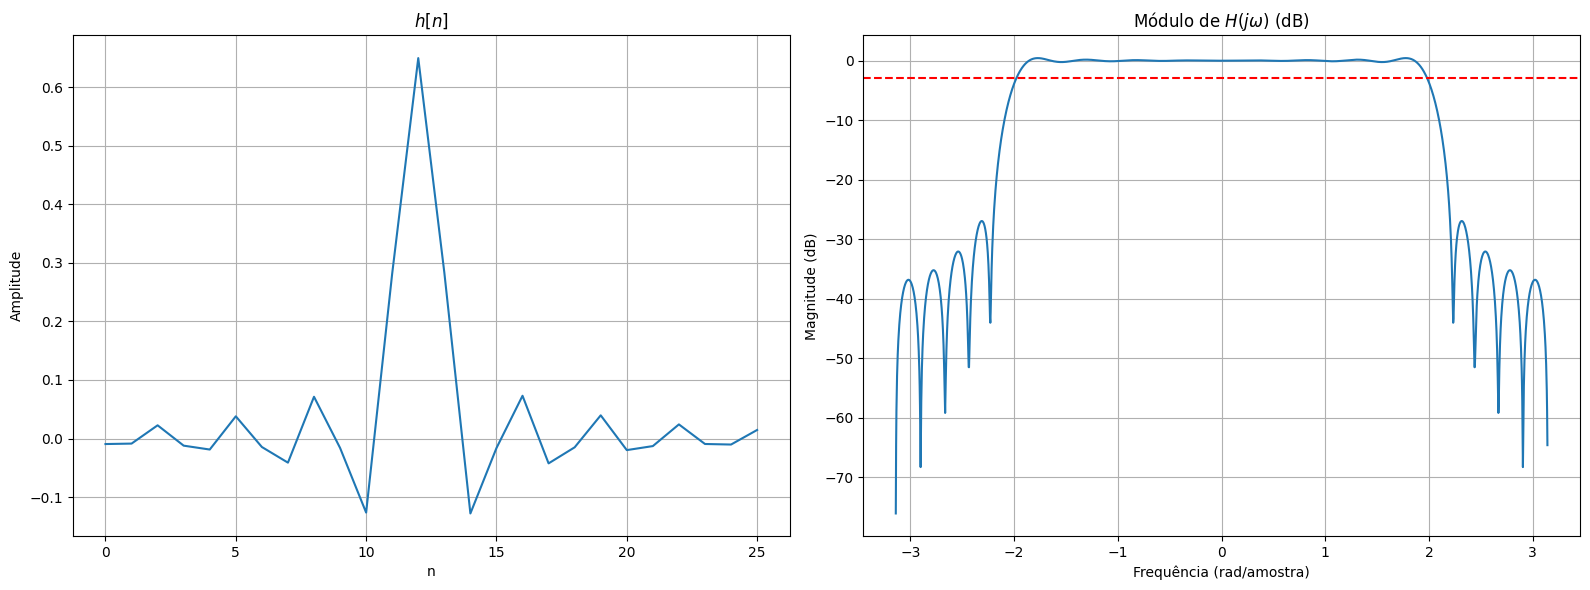

In [763]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(n, h)
axes[0].set_title("$h[n]$")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(H_frequencies, H_abs_dB)
axes[1].set_title("Módulo de $H(j\\omega)$ (dB)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].axhline(y = -3, color = 'red', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Como sabemos, um $sinc$ no tempo é uma janela retangular na na frequência. Perceba que na frequência que acontece a quedra de 3dB, é onde a frequência de corte $\omega_c$ é estipulada. Além disso, como estamos usando uma janela de kaisee, há menos lóbulos secundários relevantes na faixa de rejeitção do que na retangular. Dessa forma, o gráfico está coerente com o esperado. 

15. Gere o gráfico da resposta em fase deste sistema (com fase contínua, usando unwrap. Não esqueça de colocar as frequências corretas no eixo x. Explique, em forma de comentário em seu código, se a fase da Resposta em Frequência está de acordo com o
esperado.

Calculando a resposta em fase do sistema $h$

In [764]:
H_phase        = np.angle(H)
H_phase_unwrap = np.unwrap(H_phase)

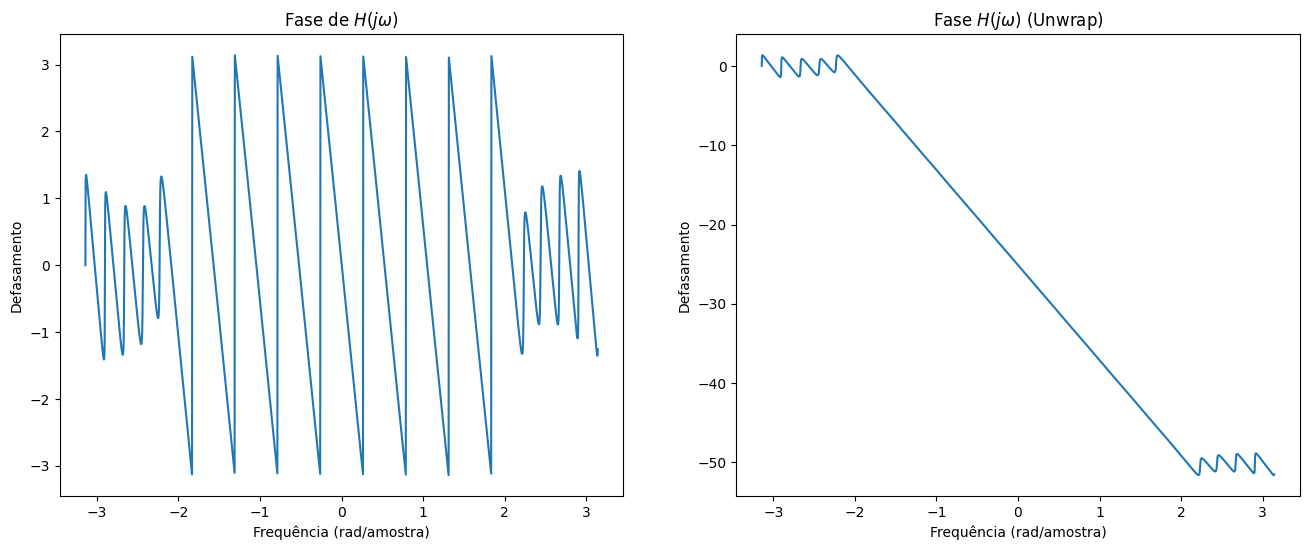

In [765]:
figure, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

axes[0].plot(H_frequencies, H_phase)
axes[0].set_title("Fase de $ H(j\\omega) $")
axes[0].set_xlabel("Frequência (rad/amostra)")
axes[0].set_ylabel("Defasamento")

axes[1].plot(H_frequencies, H_phase_unwrap)
axes[1].set_title("Fase $ H(j\\omega) $ (Unwrap)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Defasamento")

plt.show()
plt.close()

Observamos uma fase linear no intervalo do $ [-\omega_c; \omega_c] $ com declividade $ \alpha = 12 $. Portanto, o gráfico satisfaz nossas espectativas

16. Gere o gráfico do atraso de grupo deste sistema (pode usar a função pronta para o cálculo do atraso de grupo). Não esqueça de colocar as frequências corretas no eixo x.Explique, em forma de comentário em seu código, se o atraso de grupo está de acordo com o esperado.

Calculando o atraso de grupo numericamente

In [766]:
d_H_phase_unwrap = np.diff(H_phase_unwrap)
d_H_frequencies  = np.diff(H_frequencies)

H_group_delay = - d_H_phase_unwrap / d_H_frequencies

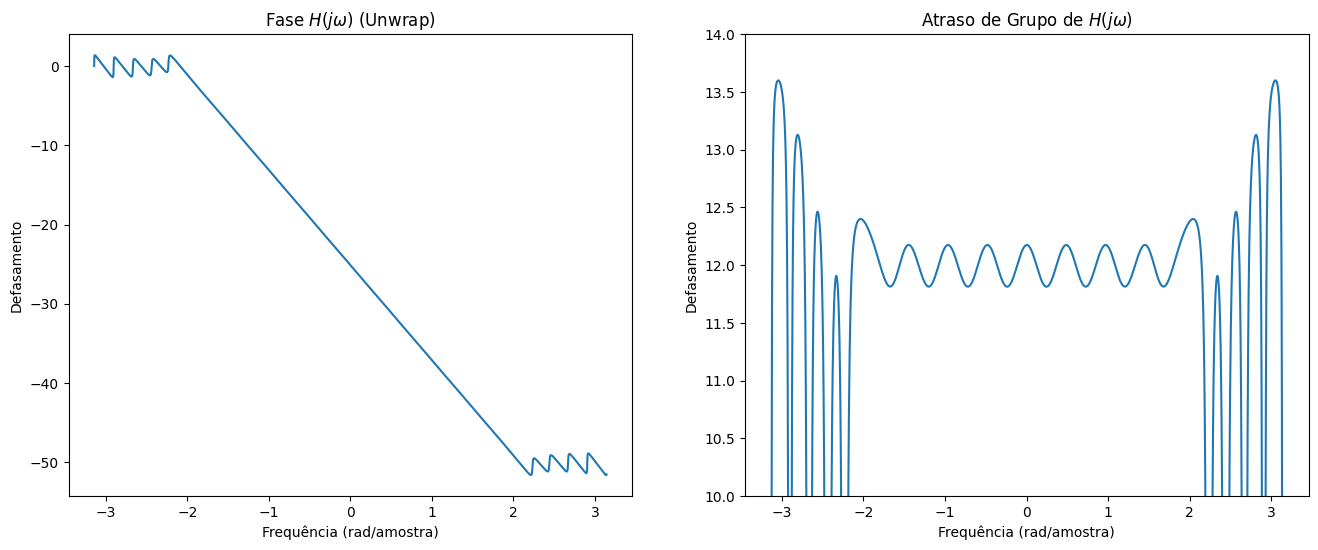

In [767]:
figure, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

axes[0].plot(H_frequencies, H_phase_unwrap)
axes[0].set_title("Fase $ H(j\\omega) $ (Unwrap)")
axes[0].set_xlabel("Frequência (rad/amostra)")
axes[0].set_ylabel("Defasamento")

axes[1].plot(H_frequencies[1:], H_group_delay)
axes[1].set_title("Atraso de Grupo de $ H(j\\omega) $")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Defasamento")
axes[1].set_ylim(10, 14)

plt.show()
plt.close()

Apesar de, graficamente, a fase parecer linear para o intervalo $[-\omega_c; \omega_c]$, o atraso de grupo não é constante. Isso é verdade porque a janela de kaiser não é uma janela retangular. Logo, o gráfico está como esperado

17. Filtre o sinal x[n] da questão 1 usando a resposta ao impulso projetada usando o método do Janelamento. Gere o gráfico do módulo da Transformada de Fourier da saída y[n] em dB. Não esqueça de colocar as frequências corretas no eixo x. Explique, em
forma de comentário em seu código, se o módulo da Transformada de Fourier do sinal filtrado está de acordo com o esperado.

Realizando a convolução de $ y[n] = x[n] \ast h[n] $

In [768]:
y   = np.convolve(x, h)
y_n = np.arange(y.size)

Calculando a Transformada de Fourier de $ y[n] $

In [769]:
N_y_fft = 2048

Y = np.fft.fft(y, N_y_fft)
Y = np.fft.fftshift(Y)

Y_abs    = np.abs(Y)
Y_abs_dB = 20 * np.log10(Y_abs)

Y_frequencies = np.linspace(-np.pi, np.pi, N_y_fft)

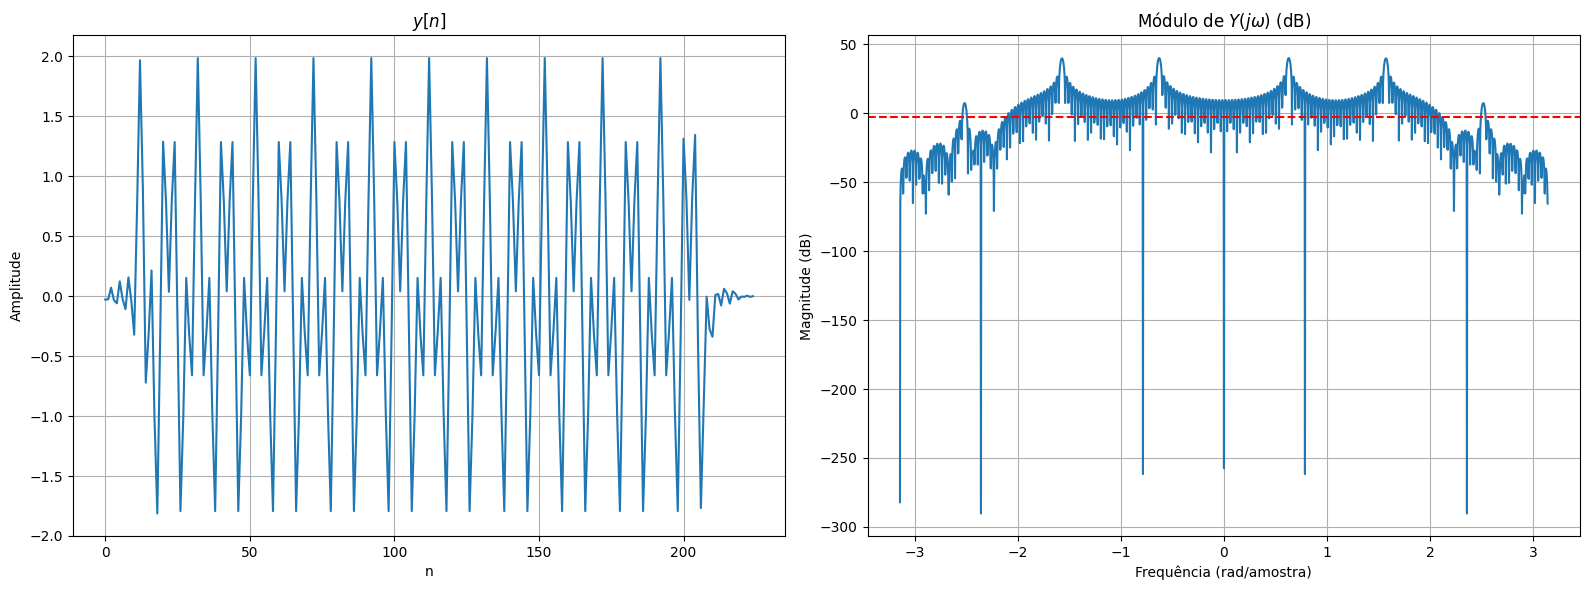

In [770]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(y_n, y)
axes[0].set_title("$y[n]$")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(Y_frequencies, Y_abs_dB)
axes[1].set_title("Módulo de $Y(j\\omega)$ (dB)")
axes[1].set_xlabel("Frequência (rad/amostra)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].axhline(y = -3, color = 'red', linestyle='--')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Como podemos notar, a componente $\cos(0.8\pi x)$ foi atenuada pelo filtro. Isso é esperado já que estamos utilizando um filtro passa-baixa com frequência de corte $ \omega_c = 0.65\pi $. Daí, componentes com frequências acima de $ \omega_c $ são atenuadas

18. O sinal de saída y[n] deve ser, de forma aproximada, igual a um sinal g[n] que
corresponde à soma de dois cossenos com frequências angulares igual a 0,2π e 0,5π, mas
com um atraso igual a α. Para saber se isto realmente está acontecendo, gere, em um
mesmo gráfico, os sinais g[n-α] e y[n], e comente se estes sinais são parecidos e
sincronizados.

Gerando o sinal $ g[n] $

In [771]:
g = np.cos(0.2 * np.pi * (y_n - alpha)) + \
    np.cos(0.5 * np.pi * (y_n - alpha))

Gerando o sinal $ e[n] = g[n] - y[n] $

In [772]:
e = g - y

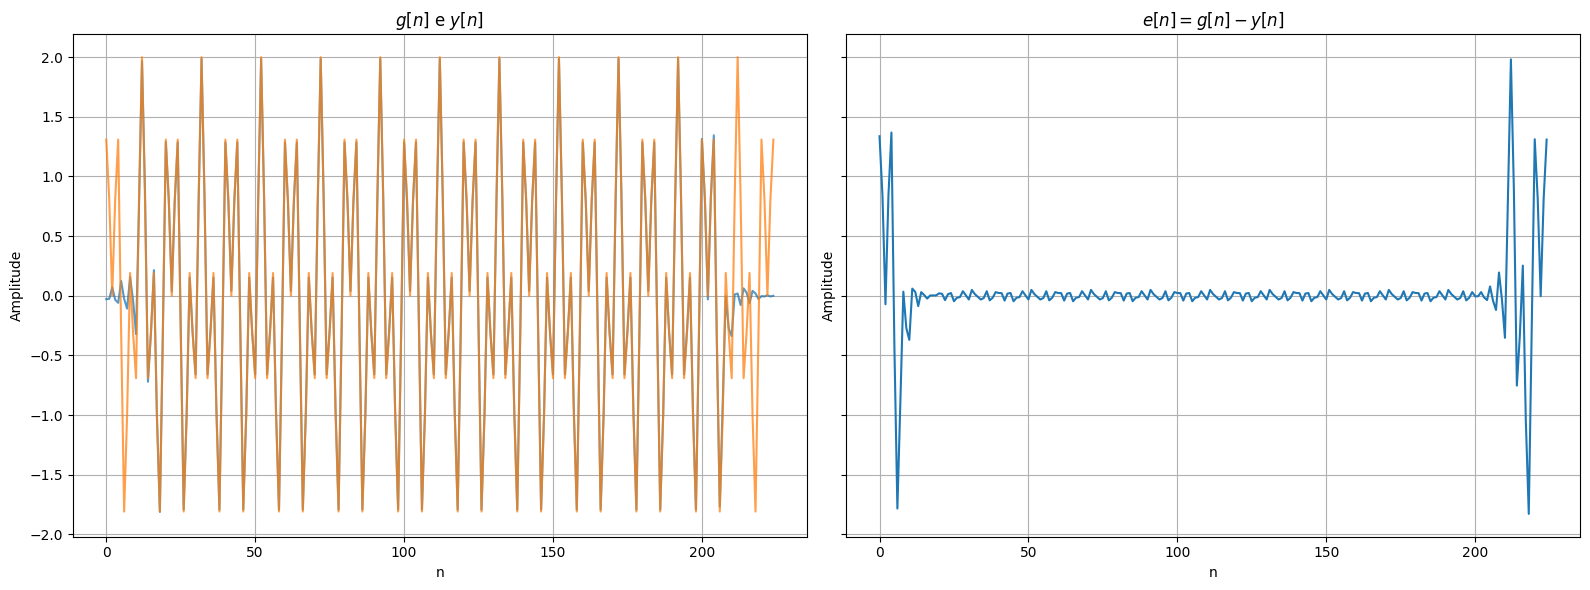

In [773]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey = True)

axes[0].plot(y_n, y, alpha = 0.75)
axes[0].plot(y_n, g, alpha = 0.75)
axes[0].set_title("$ g[n] $ e $ y[n] $")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(y_n, e)
axes[1].set_title("$ e[n] = g[n] - y[n] $")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Sim. Os gráficos são parecidos e sincronizados. Exceto nas bordas

19. Descreva, em forma de comentário no código, quais as vantagens e desvantagens dos filtros das Partes 1, 2 e 3 a partir dos gráficos gerados e da teoria vista em sala de aula.

Para o filtro usado na Parte I, filtro FIR ideal com janelamento Retangular, temos com principal vantangem o atraso de grupo constante. Em contrapartida, tem lóbulos laterais elevados

Para o filtro usado na Parte II, filtro IIR Butterworth, temos com principal vantangem a resposta em magnitude suave. Em contrapartida, não tem atraso de grupo constante o que pode distorcer o sinal de interesse

Para o filtro usado na Parte III, filtro FIR com janelamento Kaiser, temos com principal vantangem possuir um parâmetro ajustável β que a torna mais flexível. Apesar de melhor do que retangular, ainda existem lóbulos secundários e alguma ondulação na banda passante

20. Gere o diagrama de polos e zeros do filtro gerado na Parte 3. Explique, em forma de
comentário em seu código, se o diagrama de polos e zero está de acordo com o esperado.

Calculando os zeros do filtro $h$

In [774]:
h_zeros = np.roots(h[::-1])

Calculando os polos do filtro h

In [775]:
h_poles = np.zeros(h.size)

Gerando o diagram de polos e zeros

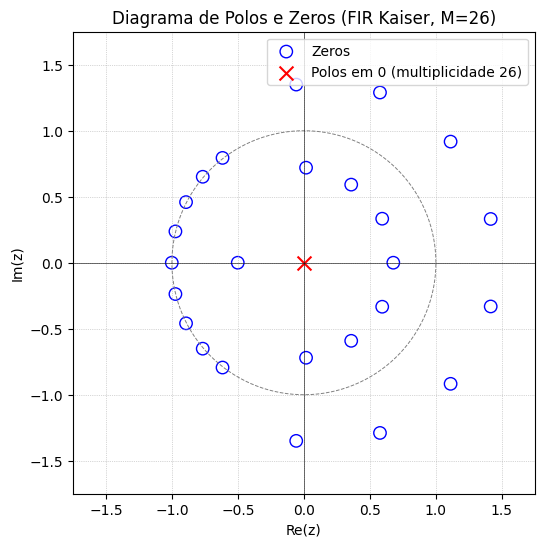

In [776]:
plt.figure(figsize=(8,6))

ax = plt.gca()

theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), linestyle='--', linewidth=0.7, color='gray')

ax.scatter(
    np.real(h_zeros), 
    np.imag(h_zeros), 
    marker='o', 
    facecolors='none', 
    edgecolors='b', 
    s=80, 
    label='Zeros'
)

ax.scatter(
    [0], 
    [0], 
    marker='x', 
    color='r', 
    s=100, 
    label=f'Polos em 0 (multiplicidade {h.size})'
)

ax.axhline(0, linewidth=0.4, color='black')
ax.axvline(0, linewidth=0.4, color='black')
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title('Diagrama de Polos e Zeros (FIR Kaiser, M=26)')
ax.set_aspect('equal', adjustable='box')
ax.legend()
ax.grid(True, linestyle=':', linewidth=0.5)

limit = 1.75
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

plt.show()
plt.close()

Como o filtro é real e possui coeficientes simétricos, seus zeros aparecem em pares complexos conjugados e, quando necessário, em pares recíprocos, o que garante tanto a linearidade de fase quanto a resposta real no domínio do tempo. Observa-se também que muitos dos zeros se alinham próximos à circunferência unitária precisamente nas regiões associadas à banda de rejeição, característica típica de filtros FIR projetados pelo método do janelamento: esses zeros “empurram” a resposta em frequência para baixo nessas faixas, produzindo a atenuação desejada. Além disso, não há polos fora da origem — o único conjunto de polos é a multiplicidade M em z = 0 decorrente do termo z⁻ᴹ, e isso está plenamente de acordo com a natureza FIR, que garante estabilidade e causalidade automática. Assim, o diagrama de polos e zeros obtido está exatamente de acordo com o esperado para um filtro FIR projetado por janela de Kaiser: zeros distribuídos de modo a esculpir a banda de rejeição e polos confinados à origem, reproduzindo fielmente a resposta em frequência anteriormente analisada.